   # Netflix Movies & TV Shows - EDA Project
# Author: Prajwal

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno


In [2]:
# Display Settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
#load dataset
df=pd.read_csv(r"../Dataset/netflix_titles.csv")

#display first 5 rows of the dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [10]:
df.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5694,s5695,Movie,White Girl,Elizabeth Wood,"Morgan Saylor, Brian 'Sene' Marc, Justin Barth...",United States,"December 2, 2016",2016,TV-MA,90 min,"Dramas, Independent Movies",A college girl romping through New York City i...
4166,s4167,TV Show,Black Earth Rising,NaN,"Michaela Coel, John Goodman, Abena Ayivor, Nom...",United Kingdom,"January 25, 2019",2018,TV-MA,1 Season,"British TV Shows, International TV Shows, TV D...",Adopted by a human rights attorney after the R...
8308,s8309,Movie,The Force,Peter Nicks,NaN,United States,"January 29, 2018",2017,TV-MA,92 min,Documentaries,This documentary follows the police of Oakland...
5063,s5064,TV Show,The Adventures of Puss in Boots,NaN,"Eric Bauza, Jayma Mays, Grey DeLisle, Paul Rug...",United States,"January 26, 2018",2018,TV-Y7,6 Seasons,"Kids' TV, TV Comedies","The world's greatest feline fighter, lover and..."
7952,s7953,Movie,Scales: Mermaids Are Real,Kevan Peterson,"Emmy Perry, Morgan Fairchild, Elisabeth Röhm, ...",United States,"January 23, 2020",2017,PG,93 min,Children & Family Movies,A seemingly ordinary girl learns she will turn...
5810,s5811,Movie,I'll Sleep When I'm Dead,Justin Krook,Steve Aoki,United States,"August 19, 2016",2016,TV-MA,80 min,"Documentaries, Music & Musicals",Superstar DJ Steve Aoki reflects on the drivin...
1440,s1441,TV Show,Nailed It! Mexico,NaN,"Omar Chaparro, Anna Ruiz","Mexico, United States","January 5, 2021",2021,TV-PG,3 Seasons,"International TV Shows, Reality TV, Spanish-La...","The fun, fondant and hilarious cake fails head..."
4108,s4109,Movie,Sur: The Melody of Life,Tanuja Chandra,"Lucky Ali, Simone Singh, Achint Kaur, Ehsan Kh...",India,"February 15, 2019",2002,TV-14,137 min,"Dramas, International Movies",A renowned music teacher mentors a promising y...
6448,s6449,Movie,Charlotte's Web,"Charles A. Nichols, Iwao Takamoto","Debbie Reynolds, Charles Nelson Reilly, Paul L...",United States,"November 23, 2019",1973,G,94 min,"Children & Family Movies, Classic Movies","Follow the adventures of Wilbur the pig, Templ..."
702,s703,Movie,Silver Linings Playbook,David O. Russell,"Bradley Cooper, Jennifer Lawrence, Robert De N...",United States,"June 17, 2021",2012,R,122 min,"Comedies, Dramas, Independent Movies",A man with bipolar disorder moves home with hi...


In [11]:
#creating  a copy of the dataset
df_clean=df.copy()

#chech the shape
df_clean.shape

(8807, 12)

In [12]:
#check duplicate rows
df_clean.duplicated().sum()

np.int64(0)

In [13]:
#count missing values in each column
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [14]:
#calculate missing values percentage
missing_percentage =(df_clean.isnull().sum()/ len(df_clean)*100).round(2)
missing_percentage

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64

In [15]:
#missing values summary
missing_summery= pd.DataFrame({"Missing_values":df_clean.isnull().sum(), "Percentage_missing":missing_percentage})
missing_summery=missing_summery[missing_summery["Missing_values"]>0]
missing_summery.sort_values(by="Percentage_missing", ascending=False)

,Missing_values,Percentage_missing
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [16]:
df_clean[df_clean["director"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [17]:
df_clean[df_clean["cast"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
...,...,...,...,...,...,...,...,...,...,...,...,...
8746,s8747,Movie,Winnie,Pascale Lamche,NaN,"France, Netherlands, South Africa, Finland","February 26, 2018",2017,TV-14,85 min,"Documentaries, International Movies",Winnie Mandela speaks about her extraordinary ...
8755,s8756,TV Show,Women Behind Bars,NaN,NaN,United States,"November 1, 2016",2010,TV-14,3 Seasons,"Crime TV Shows, Docuseries",This reality series recounts true stories of w...
8756,s8757,Movie,Woodstock,Barak Goodman,NaN,United States,"August 13, 2019",2019,TV-MA,97 min,"Documentaries, Music & Musicals",For the 50th anniversary of the legendary Wood...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...


In [18]:
df_clean[df_clean["country"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8718,s8719,Movie,Westside vs. the World,Michael Fahey,"Ron Perlman, Louie Simmons",NaN,"August 9, 2019",2019,TV-MA,96 min,"Documentaries, Sports Movies",A look into the journey of influential strengt...
8759,s8760,Movie,World's Weirdest Homes,Storm Theunissen,Charlie Luxton,NaN,"February 1, 2019",2015,TV-PG,49 min,Movies,From a bubble-shaped palace to an island built...
8783,s8784,TV Show,Yoko,NaN,"Eileen Stevens, Alyson Leigh Rosenfeld, Sarah ...",NaN,"June 23, 2018",2016,TV-Y,1 Season,Kids' TV,"Friends Mai, Oto and Vik's games at the park b..."
8785,s8786,TV Show,YOM,NaN,"Sairaj, Devyani Dagaonkar, Ketan Singh, Mayur ...",NaN,"June 7, 2018",2016,TV-Y7,1 Season,Kids' TV,"With the mind of a human being, and the body o..."


In [19]:
df_clean[df_clean["date_added"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [20]:
df_clean[df_clean["rating"].isnull()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [21]:
df_clean[df_clean["duration"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [22]:
# Fix misaligned duration values
mask = df_clean["duration"].isnull()

df_clean.loc[mask, "duration"] = df_clean.loc[mask, "rating"]

df_clean.loc[mask, "rating"] = "Not Rated"

In [23]:
# Fill missing values
df_clean["director"] = df_clean["director"].fillna("Unknown")

df_clean["cast"] = df_clean["cast"].fillna("Unknown")

df_clean["country"] = df_clean["country"].fillna("Unknown")

df_clean["rating"] = df_clean["rating"].fillna("Not Rated")

In [24]:
# Remove rows with missing date_added
df_clean.dropna(subset=["date_added"], inplace=True)


In [25]:
df_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [26]:
# Convert to datetime (strip whitespace, coerce failures)

df_clean["date_added"] = pd.to_datetime(df_clean["date_added"].str.strip(), errors='coerce')
# Show how many failed to parse
df_clean['date_added'].isna().sum()

np.int64(0)

In [27]:
df_clean["date_added"].dtype


dtype('<M8[ns]')

In [28]:
# Convert to datetime

df_clean["date_added"] = pd.to_datetime(df_clean["date_added"])

In [29]:
#create new column
# Extract Year

df_clean["added_year"] = df_clean["date_added"].dt.year

# Extract Month Name

df_clean["added_month"] = df_clean["date_added"].dt.month_name()

# Extract Day

df_clean["added_day"] = df_clean["date_added"].dt.day

# Extract Day Name

df_clean["day_name"] = df_clean["date_added"].dt.day_name()

In [31]:
# Split duration into value and unit

df_clean[["duration_value", "duration_unit"]] = (
    df_clean["duration"].str.split(" ", n=1, expand=True)
)


In [32]:
df_clean["duration_value"] = df_clean["duration_value"].astype(int)

In [33]:
df_clean[["duration", "duration_value", "duration_unit"]].head(10)

,duration,duration_value,duration_unit
0,90 min,90,min
1,2 Seasons,2,Seasons
2,1 Season,1,Season
3,1 Season,1,Season
4,2 Seasons,2,Seasons
5,1 Season,1,Season
6,91 min,91,min
7,125 min,125,min
8,9 Seasons,9,Seasons
9,104 min,104,min


In [34]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8797 non-null   object        
 1   type            8797 non-null   object        
 2   title           8797 non-null   object        
 3   director        8797 non-null   object        
 4   cast            8797 non-null   object        
 5   country         8797 non-null   object        
 6   date_added      8797 non-null   datetime64[ns]
 7   release_year    8797 non-null   int64         
 8   rating          8797 non-null   object        
 9   duration        8797 non-null   object        
 10  listed_in       8797 non-null   object        
 11  description     8797 non-null   object        
 12  added_year      8797 non-null   int32         
 13  added_month     8797 non-null   object        
 14  added_day       8797 non-null   int32         
 15  day_name 

## Business Question 1

### What is the distribution of Movies and TV Shows on Netflix?

### Objective
Analyze the distribution of Movies and TV Shows available on Netflix to understand the platform's content composition.

In [35]:
# Count content types
content_count = df_clean["type"].value_counts()

# Display counts
content_count

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [36]:
# Calculate percentages

content_percentage = (
    df_clean["type"]
    .value_counts(normalize=True)
    * 100
).round(2)

content_percentage

type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_27484\314377450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


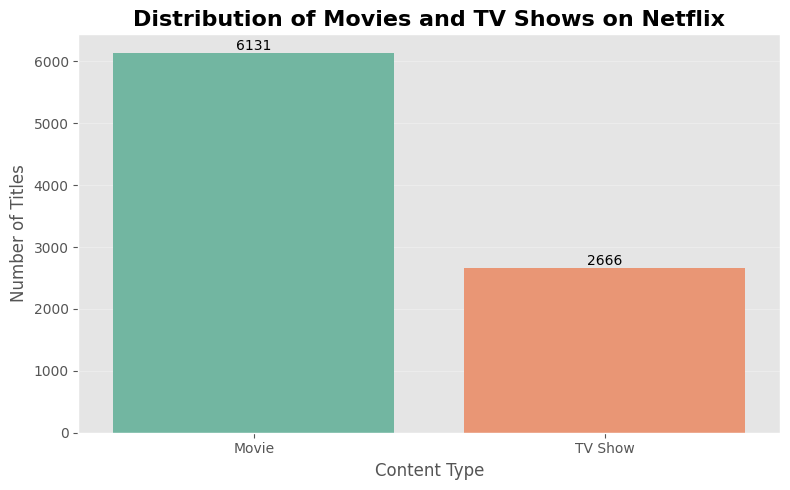

In [37]:
# Count Plot

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="type",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Movies and TV Shows on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

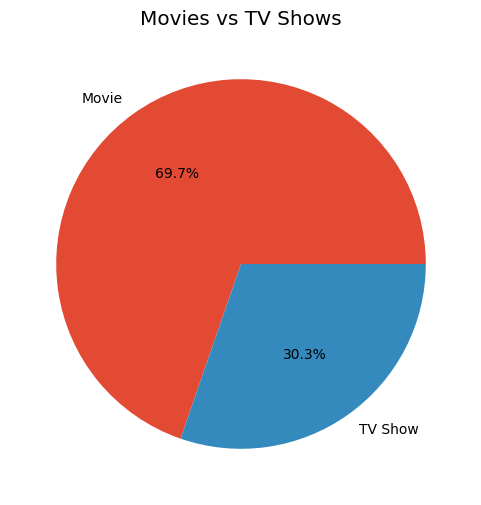

In [38]:
# Pie Chart

df_clean["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Movies vs TV Shows")

plt.ylabel("")

plt.show()

### Business Insights

- Movies account for **69.69%** of Netflix's catalog.
- TV Shows account for **30.31%** of the catalog.
- Netflix offers significantly more Movies than TV Shows.
- This indicates that Netflix's content strategy has historically focused more on Movies.

### Conclusion

The analysis shows that Movies dominate Netflix's content library. While TV Shows represent a smaller share, they still form an important part of the platform's offerings. This distribution reflects Netflix's emphasis on maintaining a larger movie catalog while continuing to expand its television content.

## Business Question 2

### Which countries produce the most Netflix content?

### Objective

Analyze the distribution of Netflix titles by country to identify the major content-producing countries available on the platform.

In [39]:
# Split multiple countries into separate rows
country_df = (
    df_clean.assign(country=df_clean["country"].str.split(", "))
            .explode("country")
)

# Display first few rows
country_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_day,day_name,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,25,Saturday,90,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,24,Friday,2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,24,Friday,1,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,24,Friday,1,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,24,Friday,2,Seasons


In [40]:
# Count titles by country

top_countries = (
    country_df["country"]
    .value_counts()
    .head(10)
)

top_countries

country
United States     3683
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

In [41]:
# Remove 'Unknown' countries
country_df_filtered = country_df[country_df["country"] != "Unknown"]

# Top 10 countries
top_countries = (
    country_df_filtered["country"]
    .value_counts()
    .head(10)
)

top_countries


country
United States     3683
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

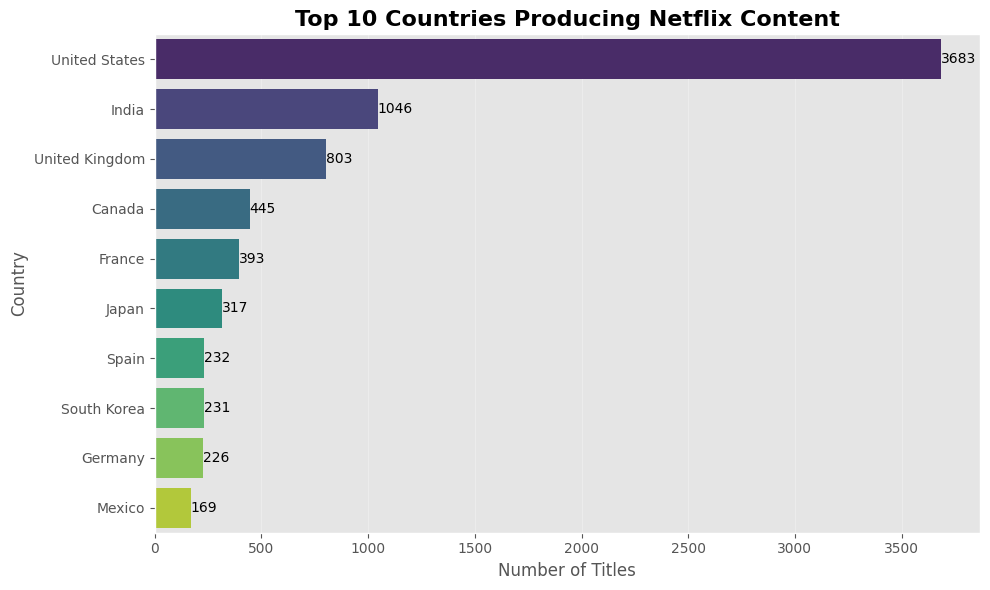

In [42]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False
)

# Add labels
for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Countries Producing Netflix Content",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## Business Insights

- The United States is the largest contributor to Netflix's content library, significantly exceeding all other countries.
- India is the second-largest contributor, highlighting Netflix's strong presence in the Indian entertainment market.
- The United Kingdom also contributes a substantial number of titles, reflecting its importance as a content production hub.
- The analysis indicates that Netflix's catalog is heavily concentrated in a few major production markets.

## Conclusion

The analysis shows that Netflix's content library is dominated by productions from the United States, followed by India and the United Kingdom. This reflects Netflix's strategic investment in major entertainment markets while maintaining a diverse international catalog.


# Business Question 3

## What are the Top 10 Most Popular Genres on Netflix?

### Objective

Analyze the genres available on Netflix to identify the most common content categories. This helps understand audience preferences and Netflix's content strategy across different genres.

In [43]:
# Split multiple genres into separate rows
genre_df = (
    df_clean.assign(listed_in=df_clean["listed_in"].str.split(", "))
            .explode("listed_in")
)

# Display first few rows
genre_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_day,day_name,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,25,Saturday,90,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,September,24,Friday,2,Seasons
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021,September,24,Friday,2,Seasons
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021,September,24,Friday,2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021,September,24,Friday,1,Season


In [44]:
# Count genre frequency

top_genres = (
    genre_df["listed_in"]
    .value_counts()
    .head(10)
)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

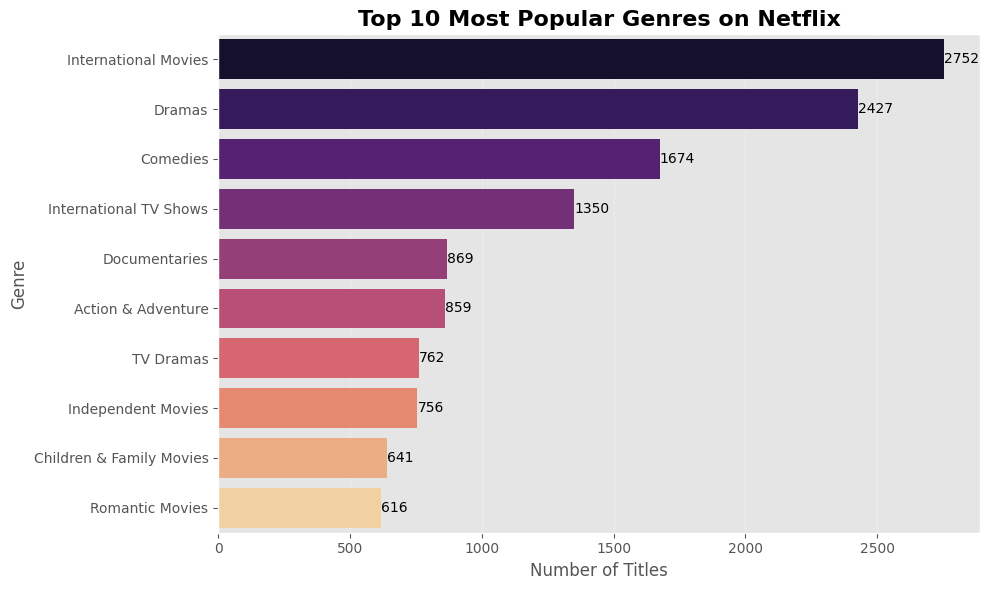

In [45]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="magma",
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Most Popular Genres on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## Business Insights

- **International Movies** is the most common genre on Netflix, with **2,752 titles**, highlighting Netflix's strong focus on global movie content.
- **Dramas** rank second with **2,427 titles**, indicating that drama is one of the platform's most popular genres.
- **Comedies** hold the third position with **1,674 titles**, showing consistent demand for entertainment-focused content.
- The presence of **International TV Shows** among the top genres demonstrates Netflix's investment in regional and multilingual content.
- Overall, Netflix's content library is dominated by movies, with a strong emphasis on international productions.

## Conclusion

The analysis reveals that Netflix's catalog is heavily focused on International Movies and Dramas, reflecting its strategy of serving a global audience with diverse content. The popularity of international genres demonstrates Netflix's commitment to expanding beyond regional entertainment and attracting viewers worldwide.

# Business Question 4

## Who are the Top 10 Directors on Netflix?

### Objective

Analyze the directors with the highest number of titles available on Netflix. This helps identify the most frequent content creators and understand Netflix's collaborations with filmmakers.

In [46]:
# Remove Unknown directors before analysis
director_df = df_clean[df_clean["director"] != "Unknown"]

# Split multiple directors into separate rows
director_df = (
    director_df.assign(director=director_df["director"].str.split(", "))
               .explode("director")
)

# Display first few rows
director_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_day,day_name,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,25,Saturday,90,min
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,24,Friday,1,Season
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,September,24,Friday,1,Season
6,s7,Movie,My Little Pony: A New Generation,Robert Cullen,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,September,24,Friday,91,min
6,s7,Movie,My Little Pony: A New Generation,José Luis Ucha,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,September,24,Friday,91,min


In [47]:
# Count director frequency

top_directors = (
    director_df["director"]
    .value_counts()
    .head(10)
)

top_directors

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

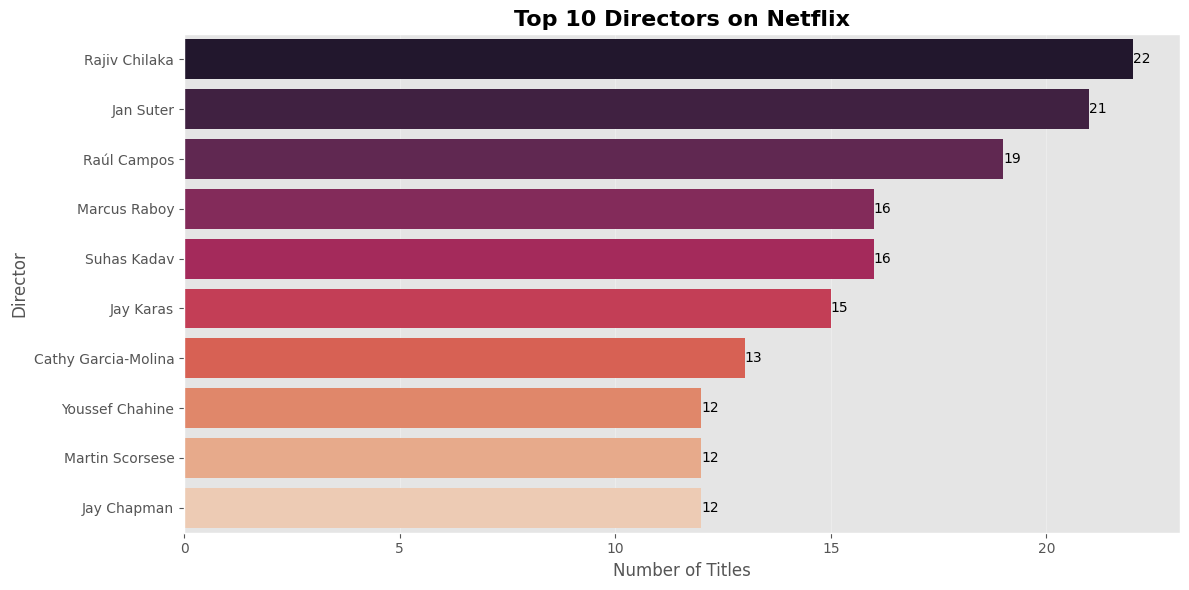

In [48]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette="rocket",
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top 10 Directors on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## Business Insights

- **Rajiv Chilaka** is the most featured director on Netflix with **22 titles**, making him the leading contributor in this dataset.
- **Jan Suter** ranks second with **21 titles**, followed by **Raúl Campos** with **19 titles**.
- The top directors have consistently contributed multiple titles, indicating strong collaboration between Netflix and these filmmakers.
- The distribution also shows that Netflix works with a diverse range of directors rather than relying on a single creator.

## Conclusion

The analysis shows that Rajiv Chilaka, Jan Suter, and Raúl Campos are among the most represented directors on Netflix. This highlights Netflix's partnerships with directors who have contributed multiple titles across different genres and regions.

# Business Question 5

## How has Netflix's content library grown over the years?

### Objective

Analyze the number of titles added to Netflix each year to understand the platform's content growth and identify periods of rapid expansion.

In [49]:
# ==========================================================
# Business Question 5
# How has Netflix's content library grown over the years?
# ==========================================================

# Count titles added each year

yearly_content = (
    df_clean["added_year"]
    .value_counts()
    .sort_index()
)

yearly_content

added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

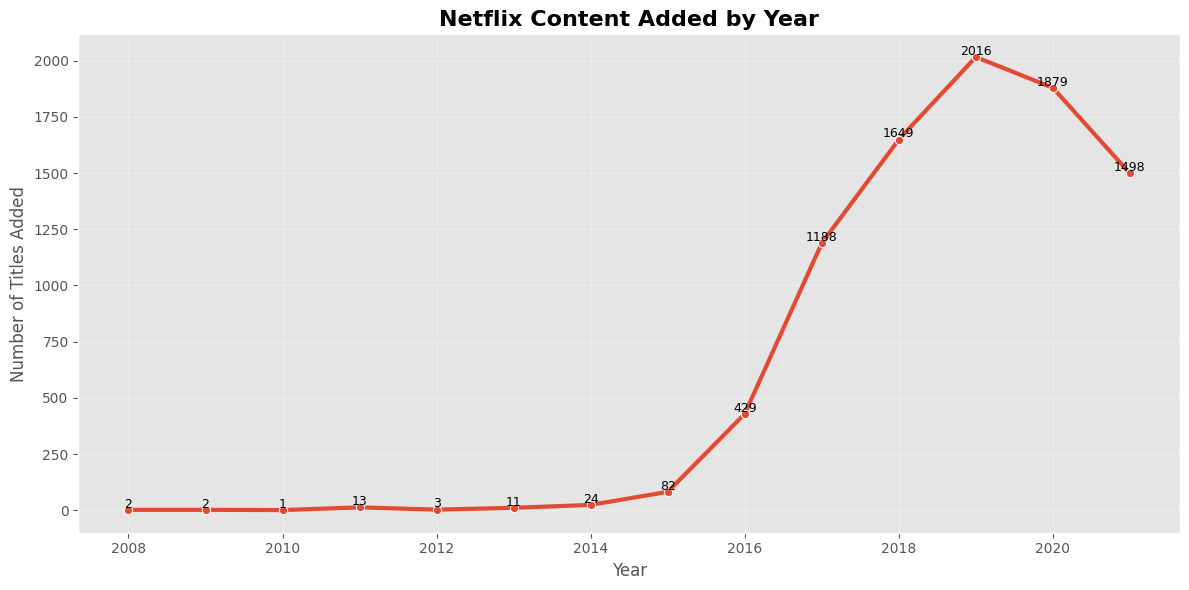

In [50]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    x=yearly_content.index,
    y=yearly_content.values,
    marker="o",
    linewidth=3
)

# Add value labels
for x, y in zip(yearly_content.index, yearly_content.values):
    plt.text(
        x,
        y + 10,
        str(y),
        ha="center",
        fontsize=9
    )

plt.title(
    "Netflix Content Added by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Number of Titles Added")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Business Insights

- Netflix experienced **rapid growth** in content additions between **2016 and 2019**, indicating a major expansion of its content library.
- The platform reached its **highest number of content additions in 2019**, with **2,016 titles** added.
- Although content additions declined after 2019, Netflix continued to add a substantial number of titles in **2020** and **2021**, demonstrating sustained investment in content.
- The trend reflects Netflix's aggressive global expansion strategy and increasing investment in original and licensed content during this period.

## Conclusion

The analysis shows that Netflix significantly expanded its content library between 2016 and 2019, reaching a peak in 2019. While content additions declined slightly after the peak, Netflix maintained a strong content acquisition strategy, reflecting its commitment to serving a global audience.

# 6. Ratings Distribution on Netflix

## Objective

Analyze the distribution of content ratings on Netflix to understand the target audience and identify which age categories dominate the platform.

In [51]:
# ==========================================================
# Business Question 6
# What are the most common content ratings on Netflix?
# ==========================================================

# Count ratings

rating_counts = (
    df_clean["rating"]
    .value_counts()
)

rating_counts

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
Not Rated       7
TV-Y7-FV        6
NC-17           3
UR              3
Name: count, dtype: int64

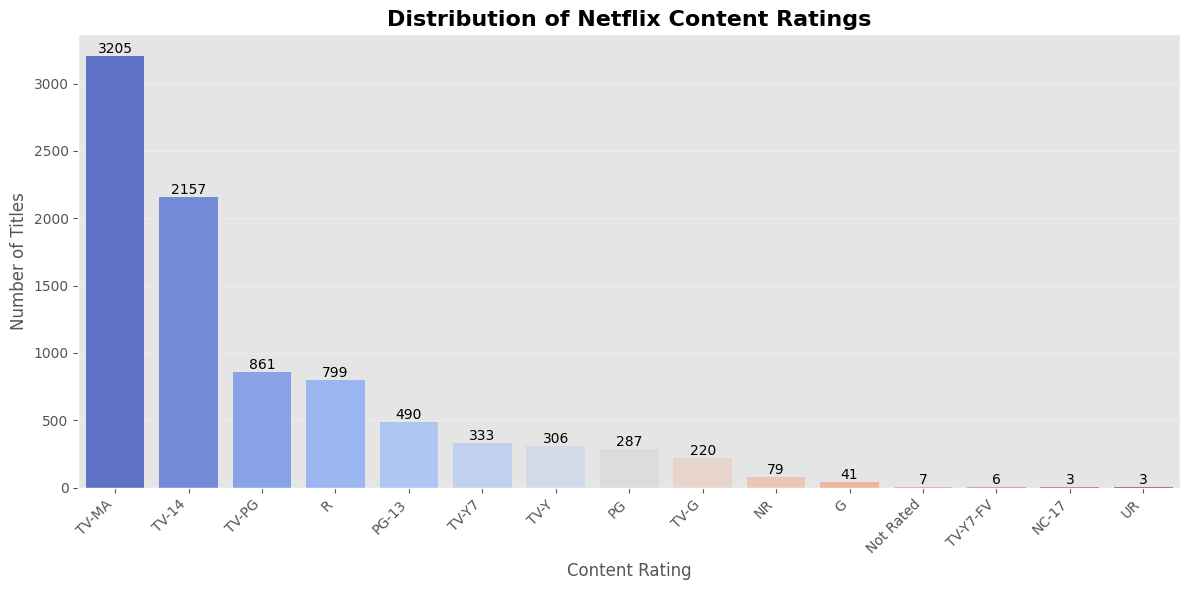

In [53]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    hue=rating_counts.index,
    palette="coolwarm",
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)
    plt.xticks(rotation=45, ha="right")

plt.title(
    "Distribution of Netflix Content Ratings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Business Insights

- **TV-MA** is the most common content rating on Netflix, with **3,205 titles**, indicating that a large portion of the catalog is intended for mature audiences.
- **TV-14** ranks second with **2,157 titles**, showing a strong focus on content suitable for teenagers and young adults.
- Family-friendly ratings such as **TV-PG**, **TV-Y7**, **TV-Y**, and **TV-G** are also well represented, reflecting Netflix's effort to serve viewers across different age groups.
- Ratings such as **NC-17**, **UR**, and **TV-Y7-FV** appear very rarely, indicating limited availability of highly specialized content categories.

## Conclusion

The analysis shows that Netflix primarily focuses on mature and teenage audiences, as reflected by the dominance of TV-MA and TV-14 rated content. At the same time, the platform maintains a balanced catalog with family-friendly titles to cater to a broad range of viewers.

# 7. Movie Duration Analysis

## Objective

Analyze the duration of Netflix movies to understand the distribution of movie lengths and identify the typical runtime of movies available on the platform.

In [54]:
# ==========================================================
# Business Question 7
# What is the distribution of movie durations on Netflix?
# ==========================================================

# Filter only movies

movies_df = df_clean[df_clean["type"] == "Movie"]

# Display first few rows (Optional)
movies_df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_day,day_name,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,25,Saturday,90,min
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,September,24,Friday,91,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,September,24,Friday,125,min
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,September,24,Friday,104,min
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,September,23,Thursday,127,min


In [55]:
# Summary statistics

movies_df["duration_value"].describe()


count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

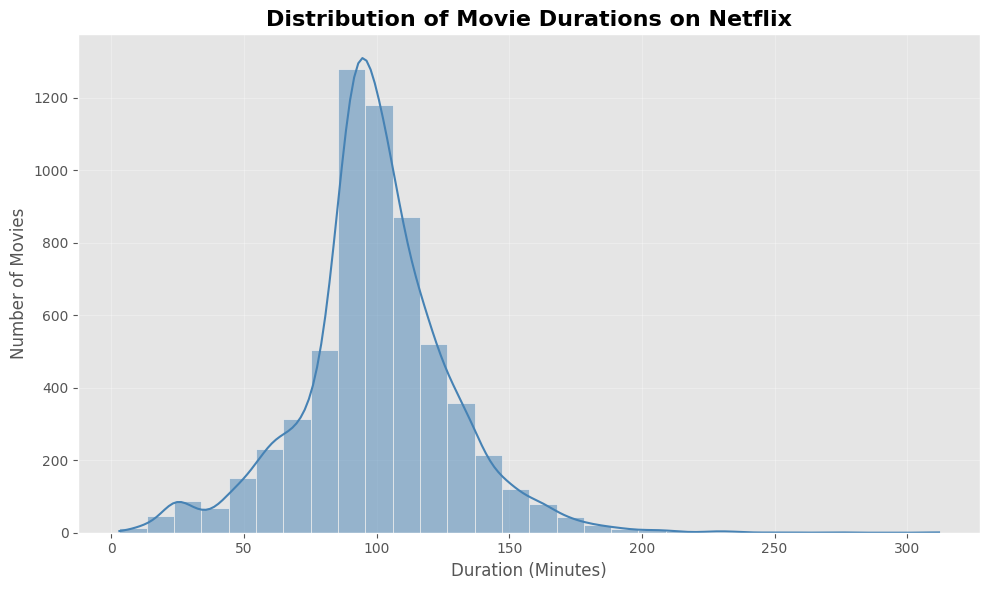

In [56]:
plt.figure(figsize=(10,6))

sns.histplot(
    movies_df["duration_value"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribution of Movie Durations on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [57]:
# Average movie duration

average_duration = movies_df["duration_value"].mean()

print(f"Average Movie Duration: {average_duration:.2f} minutes")

Average Movie Duration: 99.56 minutes


## Business Insights

- The average duration of Netflix movies is approximately **100 minutes**, indicating that most titles are standard feature-length films.
- Most movies fall between **87 and 114 minutes**, suggesting that Netflix primarily offers medium-length content suitable for general audiences.
- The distribution is centered around **90–110 minutes**, where the highest concentration of movies is observed.
- A small number of movies have exceptionally long durations (over **200 minutes**), but these are relatively rare.

## Conclusion

The analysis indicates that Netflix's movie catalog is dominated by standard feature-length films, with most titles lasting around 100 minutes. While a few exceptionally long movies exist, the majority of the catalog follows a consistent runtime that aligns with audience viewing preferences.

# 8. Monthly Content Addition Trend

## Objective

Analyze the monthly trend of content added to Netflix to identify seasonal patterns and determine which months have the highest number of new titles.

In [58]:
# ==========================================================
# Business Question 8
# Which months have the highest content additions?
# ==========================================================

# Define month order

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

# Count monthly additions

monthly_content = (
    df_clean["added_month"]
    .value_counts()
    .reindex(month_order)
)

monthly_content

added_month
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64

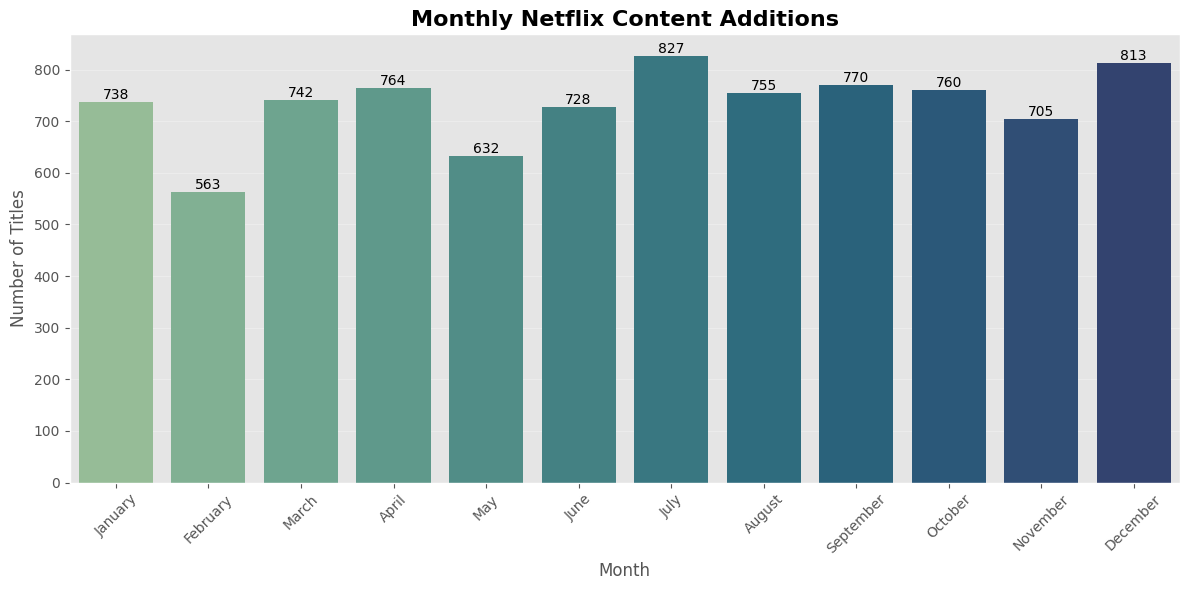

In [59]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=monthly_content.index,
    y=monthly_content.values,
    hue=monthly_content.index,
    palette="crest",
    legend=False
)

# Add labels

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Monthly Netflix Content Additions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Business Insights

- **July** recorded the highest number of content additions (**827 titles**), making it the busiest month for Netflix content releases.
- **December** ranked second with **813 titles**, indicating increased content additions during the holiday season.
- **February** had the lowest number of additions (**563 titles**), suggesting comparatively lower content releases during that month.
- Overall, Netflix adds content consistently throughout the year, with noticeable peaks during the middle and end of the year.

## Conclusion

The monthly trend analysis shows that Netflix maintains a steady content release schedule throughout the year while increasing additions during certain months such as July and December. These peaks may reflect strategic release planning to maximize audience engagement during high-viewership periods.

In [61]:
# Save the cleaned dataset to a new CSV file
df_clean.to_csv("netflix_cleaned.csv", index=False)